# Notebook 2C — Climate visual analytics and ML-table construction

This notebook uses Notebook 1C outputs to construct climate niche analytics and the climate taxon–compound table for Notebook 3C.

Climate is treated as an ecological niche layer. Compound evidence is annotation, not measured metabolite accumulation.

In [1]:
# ============================================================
# 0. Imports and configuration
# ============================================================

import os
import re
import json
import pathlib
import warnings
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

try:
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.stats import spearmanr
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 220)

CONFIG = {
    "project_dir": "climate_notebook2_outputs",
    "input_dirs": [
        ".",
        "/content",
        "/mnt/data",
        "/content/climate_medicinal_value_dataset_v1",
        "/content/climate_medicinal_value_dataset_v1/derived",
        "/content/climate_medicinal_value_dataset_v1/climate",
        "/content/climate_medicinal_value_dataset_v1/metadata",
    ],
    "curated_positive_pairs": [
        ("TAX_RHODIOLA", "CMP_SALIDROSIDE"),
        ("TAX_RHODIOLA", "CMP_TYROSOL"),
        ("TAX_HYPERICUM", "CMP_HYPERICIN"),
        ("TAX_HYPERICUM", "CMP_TOTAL_FLAVONOIDS"),
        ("TAX_HYPERICUM", "CMP_TOTAL_PHENOLICS"),
        ("TAX_ARTEMISIA_ANNUA", "CMP_ARTEMISININ"),
        ("TAX_GLYCYRRHIZA_GLABRA", "CMP_GLYCYRRHIZIN"),
        ("TAX_SEDUM", "CMP_TOTAL_FLAVONOIDS"),
        ("TAX_SEDUM", "CMP_TOTAL_PHENOLICS"),
        ("TAX_TAXUS", "CMP_PACLITAXEL"),
    ],
    "figure_dpi": 300,
    "save_pdf": True,
    "random_seed": 42,
}

PROJECT = pathlib.Path(CONFIG["project_dir"]).resolve()
DIRS = {"derived": PROJECT / "derived", "figures": PROJECT / "figures", "tables": PROJECT / "tables"}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

RUN_ID = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%dT%H%M%SZ")
PROJECT

PosixPath('/content/climate_notebook2_outputs')

In [2]:
# ============================================================
# 1. Utilities
# ============================================================

def safe_name(x, max_len=160):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(x)).strip("_")[:max_len]

def find_input_file(filename, required=True):
    candidates = []
    for d in CONFIG["input_dirs"]:
        d = pathlib.Path(d)
        candidates.append(d / filename)
        if d.exists() and d.is_dir():
            candidates.extend(d.rglob(filename))
    existing = sorted(set([p for p in candidates if p.exists() and p.stat().st_size > 0]), key=lambda p: (len(str(p)), str(p)))
    if not existing:
        if required:
            raise FileNotFoundError(f"Could not find {filename}. Add its folder to CONFIG['input_dirs'].")
        return None
    return existing[0]

def load_tsv(filename, required=True):
    p = find_input_file(filename, required=required)
    if p is None:
        return pd.DataFrame()
    df = pd.read_csv(p, sep="\t", dtype=str, low_memory=False)
    df.attrs["source_path"] = str(p)
    print(f"Loaded {filename}: {df.shape} from {p}")
    return df

def write_table(df, path_stem):
    path_stem.parent.mkdir(parents=True, exist_ok=True)
    tsv = path_stem.with_suffix(".tsv")
    df.to_csv(tsv, sep="\t", index=False)
    try:
        df.to_parquet(path_stem.with_suffix(".parquet"), index=False)
    except Exception as e:
        print("Parquet skipped:", e)
    return tsv

def save_figure(fig, name):
    png = DIRS["figures"] / f"{safe_name(name)}.png"
    fig.savefig(png, dpi=CONFIG["figure_dpi"], bbox_inches="tight")
    if CONFIG["save_pdf"]:
        fig.savefig(DIRS["figures"] / f"{safe_name(name)}.pdf", bbox_inches="tight")
    print("Saved:", png)

def panel(ax, label):
    ax.text(-0.10, 1.08, label, transform=ax.transAxes, fontsize=15, fontweight="bold", va="top")

def zscore_df(df):
    num = df.apply(pd.to_numeric, errors="coerce")
    return (num - num.mean(axis=0)) / num.std(axis=0).replace(0, np.nan)

def short_climate_name(x):
    return str(x).replace("clim_", "").replace("_", " ")

In [7]:
# ============================================================
# 2. Load Notebook 1C outputs
# ============================================================
import zipfile
import os

zip_path = "/content/notebook_outputs_20260515T063115Z.zip"
if os.path.exists(zip_path):
    extract_dir = "/content/extracted_notebook_outputs"
    print(f"Extracting {zip_path} to {extract_dir}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    if extract_dir not in CONFIG["input_dirs"]:
        CONFIG["input_dirs"].append(extract_dir)

occ_climate_df = load_tsv("occurrence_climate_features.tsv", required=False)
climate_taxon_df = load_tsv("climate_taxon_summary.tsv", required=False)
climate_point_wide_df = load_tsv("climate_point_features_wide.tsv", required=False)
climate_long_df = load_tsv("climate_point_features_long.tsv", required=False)
target_taxa_df = load_tsv("target_taxa_config.tsv", required=False)
target_compounds_df = load_tsv("target_compounds_config.tsv", required=False)
coverage_df = load_tsv("climate_coverage_by_taxon_v1.tsv", required=False)

for df in [occ_climate_df, climate_taxon_df, target_taxa_df]:
    if "taxon_id" in df:
        df["taxon_id"] = df["taxon_id"].astype(str)

climate_feature_cols = [
    c for c in occ_climate_df.columns
    if c.startswith("clim_")
    and pd.to_numeric(occ_climate_df[c], errors="coerce").notna().sum() >= 3
    and pd.to_numeric(occ_climate_df[c], errors="coerce").nunique(dropna=True) > 1
]
print("Climate feature columns:", len(climate_feature_cols))


Extracting /content/notebook_outputs_20260515T063115Z.zip to /content/extracted_notebook_outputs...
Loaded occurrence_climate_features.tsv: (2763, 102) from extracted_notebook_outputs/derived/occurrence_climate_features.tsv
Loaded climate_taxon_summary.tsv: (6, 260) from extracted_notebook_outputs/derived/climate_taxon_summary.tsv
Loaded climate_point_features_wide.tsv: (222, 67) from extracted_notebook_outputs/climate/climate_point_features_wide.tsv
Loaded climate_point_features_long.tsv: (20202, 12) from extracted_notebook_outputs/climate/climate_point_features_long.tsv
Loaded target_taxa_config.tsv: (6, 5) from extracted_notebook_outputs/metadata/target_taxa_config.tsv
Loaded target_compounds_config.tsv: (8, 5) from extracted_notebook_outputs/metadata/target_compounds_config.tsv
Loaded climate_coverage_by_taxon_v1.tsv: (6, 9) from extracted_notebook_outputs/derived/climate_coverage_by_taxon_v1.tsv
Climate feature columns: 62


In [10]:
# ============================================================
# 3. Build target and ML tables
# ============================================================

target_rows = []
curated_pairs = set(CONFIG["curated_positive_pairs"])

for _, tax in target_taxa_df.iterrows():
    for _, comp in target_compounds_df.iterrows():
        pair = (tax.get("taxon_id"), comp.get("compound_id"))
        is_pos = pair in curated_pairs
        target_rows.append({
            "taxon_id": tax.get("taxon_id"),
            "scientific_name": tax.get("scientific_name"),
            "family": tax.get("family", ""),
            "rank": tax.get("rank", ""),
            "compound_id": comp.get("compound_id"),
            "compound_name": comp.get("compound_name"),
            "compound_class": comp.get("compound_class", ""),
            "compound_record_type": comp.get("record_type", ""),
            "is_curated_positive_pair": int(is_pos),
            "target_evidence_score": 3 if is_pos else 0,
            "target_label_for_open_data_classifier": int(is_pos),
            "target_evidence_class": "curated_strong_positive" if is_pos else "background_pseudo_negative",
            "target_warning": "Score 0 is background/pseudo-negative, not confirmed biological absence.",
        })

if len(target_rows) > 0:
    target_df = pd.DataFrame(target_rows)
else:
    target_df = pd.DataFrame(columns=["taxon_id", "scientific_name", "family", "rank", "compound_id", "compound_name"])

write_table(target_df, DIRS["derived"] / "climate_taxon_compound_target_table")

base_occ = occ_climate_df.copy()
if "taxon_id" not in base_occ.columns:
    base_occ["taxon_id"] = ""

ml_table = base_occ.merge(target_df.drop(columns=["scientific_name", "family", "rank"], errors="ignore"), on="taxon_id", how="inner")
ml_table["taxonomic_group_id"] = ml_table.get("family", "").astype(str) + "__" + ml_table.get("taxon_id", "").astype(str)
ml_table["compound_group_id"] = ml_table.get("compound_class", "").astype(str)
ml_table["spatial_group_id"] = ml_table.get("spatial_block_id", "").astype(str)
ml_table["source_group_id"] = "climate_gbif_nasa_power_open_data"
ml_table = ml_table.reset_index(drop=True)
ml_table["ml_row_id"] = ["CLIMML_" + str(i).zfill(9) for i in range(len(ml_table))]
if "ml_row_id" in ml_table.columns:
    ml_table = ml_table[["ml_row_id"] + [c for c in ml_table.columns if c != "ml_row_id"]]

# Convert climate columns to numeric before aggregation
for c in climate_feature_cols:
    if c in ml_table.columns:
        ml_table[c] = pd.to_numeric(ml_table[c], errors="coerce")

write_table(ml_table, DIRS["derived"] / "climate_taxon_occurrence_compound_ml_table")

named_agg = {
    "target_evidence_score": ("target_evidence_score", "max"),
    "target_label_for_open_data_classifier": ("target_label_for_open_data_classifier", "max"),
    "n_occurrences": ("ml_row_id", "count"),
    "n_spatial_blocks": ("spatial_group_id", "nunique"),
}
for c in climate_feature_cols:
    named_agg[f"{c}__mean"] = (c, "mean")
    named_agg[f"{c}__sd"] = (c, "std")

if len(ml_table) > 0:
    primary_df = (
        ml_table
        .groupby(["taxon_id", "input_taxon", "compound_id", "compound_name", "compound_class"], dropna=False)
        .agg(**named_agg)
        .reset_index()
        .rename(columns={"input_taxon": "scientific_name"})
    )
else:
    primary_df = pd.DataFrame(columns=["taxon_id", "scientific_name", "compound_id", "compound_name", "compound_class"])

write_table(primary_df, DIRS["derived"] / "climate_primary_taxon_compound_table")

print("ML table:", ml_table.shape)
print("Primary table:", primary_df.shape)
primary_df.head()


ML table: (22104, 116)
Primary table: (48, 133)


,taxon_id,scientific_name,compound_id,compound_name,compound_class,target_evidence_score,target_label_for_open_data_classifier,n_occurrences,n_spatial_blocks,clim_tmean_annual__mean,clim_tmean_annual__sd,clim_tmean_seasonality_sd__mean,clim_tmean_seasonality_sd__sd,clim_tmean_range__mean,clim_tmean_range__sd,clim_tmax_warmest_month__mean,clim_tmax_warmest_month__sd,clim_tmin_coldest_month__mean,clim_tmin_coldest_month__sd,clim_temp_extreme_range__mean,clim_temp_extreme_range__sd,clim_mean_diurnal_range__mean,clim_mean_diurnal_range__sd,clim_precip_annual__mean,clim_precip_annual__sd,clim_precip_wettest_month__mean,clim_precip_wettest_month__sd,clim_precip_driest_month__mean,clim_precip_driest_month__sd,clim_precip_seasonality_cv__mean,clim_precip_seasonality_cv__sd,clim_aridity_index_precip_over_tmean_plus10__mean,clim_aridity_index_precip_over_tmean_plus10__sd,clim_precip_wettest_quarter__mean,clim_precip_wettest_quarter__sd,clim_precip_driest_quarter__mean,clim_precip_driest_quarter__sd,clim_tmean_warmest_quarter__mean,clim_tmean_warmest_quarter__sd,clim_tmean_coldest_quarter__mean,clim_tmean_coldest_quarter__sd,clim_tmean_wettest_quarter__mean,clim_tmean_wettest_quarter__sd,clim_tmean_driest_quarter__mean,clim_tmean_driest_quarter__sd,clim_precip_warmest_quarter__mean,clim_precip_warmest_quarter__sd,clim_precip_coldest_quarter__mean,clim_precip_coldest_quarter__sd,clim_rh2m_annual__mean,clim_rh2m_annual__sd,clim_rh2m_seasonality_sd__mean,clim_rh2m_seasonality_sd__sd,clim_solar_annual_mean__mean,clim_solar_annual_mean__sd,clim_solar_seasonality_sd__mean,clim_solar_seasonality_sd__sd,clim_wind_annual_mean__mean,clim_wind_annual_mean__sd,clim_wind_seasonality_sd__mean,clim_wind_seasonality_sd__sd,clim_T2M_JAN__mean,clim_T2M_JAN__sd,clim_PRECTOTCORR_JAN__mean,clim_PRECTOTCORR_JAN__sd,clim_RH2M_JAN__mean,clim_RH2M_JAN__sd,clim_T2M_FEB__mean,clim_T2M_FEB__sd,clim_PRECTOTCORR_FEB__mean,clim_PRECTOTCORR_FEB__sd,clim_RH2M_FEB__mean,clim_RH2M_FEB__sd,clim_T2M_MAR__mean,clim_T2M_MAR__sd,clim_PRECTOTCORR_MAR__mean,clim_PRECTOTCORR_MAR__sd,clim_RH2M_MAR__mean,clim_RH2M_MAR__sd,clim_T2M_APR__mean,clim_T2M_APR__sd,clim_PRECTOTCORR_APR__mean,clim_PRECTOTCORR_APR__sd,clim_RH2M_APR__mean,clim_RH2M_APR__sd,clim_T2M_MAY__mean,clim_T2M_MAY__sd,clim_PRECTOTCORR_MAY__mean,clim_PRECTOTCORR_MAY__sd,clim_RH2M_MAY__mean,clim_RH2M_MAY__sd,clim_T2M_JUN__mean,clim_T2M_JUN__sd,clim_PRECTOTCORR_JUN__mean,clim_PRECTOTCORR_JUN__sd,clim_RH2M_JUN__mean,clim_RH2M_JUN__sd,clim_T2M_JUL__mean,clim_T2M_JUL__sd,clim_PRECTOTCORR_JUL__mean,clim_PRECTOTCORR_JUL__sd,clim_RH2M_JUL__mean,clim_RH2M_JUL__sd,clim_T2M_AUG__mean,clim_T2M_AUG__sd,clim_PRECTOTCORR_AUG__mean,clim_PRECTOTCORR_AUG__sd,clim_RH2M_AUG__mean,clim_RH2M_AUG__sd,clim_T2M_SEP__mean,clim_T2M_SEP__sd,clim_PRECTOTCORR_SEP__mean,clim_PRECTOTCORR_SEP__sd,clim_RH2M_SEP__mean,clim_RH2M_SEP__sd,clim_T2M_OCT__mean,clim_T2M_OCT__sd,clim_PRECTOTCORR_OCT__mean,clim_PRECTOTCORR_OCT__sd,clim_RH2M_OCT__mean,clim_RH2M_OCT__sd,clim_T2M_NOV__mean,clim_T2M_NOV__sd,clim_PRECTOTCORR_NOV__mean,clim_PRECTOTCORR_NOV__sd,clim_RH2M_NOV__mean,clim_RH2M_NOV__sd,clim_T2M_DEC__mean,clim_T2M_DEC__sd,clim_PRECTOTCORR_DEC__mean,clim_PRECTOTCORR_DEC__sd,clim_RH2M_DEC__mean,clim_RH2M_DEC__sd
0,TAX_ARTEMISIA_ANNUA,Artemisia annua,CMP_ARTEMISININ,artemisinin,sesquiterpene lactone,3,1,512,49,11.541979,3.895655,8.007626,2.295932,21.67877,6.355988,38.520449,4.03053,-16.84043,9.427845,55.360879,9.878565,30.758239,5.536885,28.548145,12.2846,3.464844,1.926346,1.420918,0.903662,33.126814,27.167568,1.351272,0.569581,9.357129,4.473636,5.049688,2.912367,21.387676,4.02663,1.68069,5.680871,16.080384,6.031235,8.104701,10.452158,8.007656,4.766907,6.315137,2.551298,74.567826,12.5643,7.73993,4.913965,13.795067,2.392934,6.565142,1.010711,2.549709,1.075875,0.385629,0.182291,1.589082,7.90176,2.068086,0.834135,83.18332,10.112036,2.561074,7.22402,2.183965,0.863418,81.262871,9.691592,6.21707,5.578952,2.226152,0.926461,77.827969,9.568393,10.738926,3.882295,2.20341

In [12]:
# ============================================================
# 4. PCA, correlation, and profiles
# ============================================================

clim_numeric = occ_climate_df[climate_feature_cols].apply(pd.to_numeric, errors="coerce")
clim_numeric = clim_numeric.loc[:, clim_numeric.notna().sum() > 2]
clim_numeric = clim_numeric.loc[:, clim_numeric.nunique(dropna=True) > 1]

X = SimpleImputer(strategy="median").fit_transform(clim_numeric)
X = StandardScaler().fit_transform(X)

n_components = min(5, X.shape[0], X.shape[1])
pca = PCA(n_components=n_components, random_state=CONFIG["random_seed"])
scores = pca.fit_transform(X)

pca_scores_df = occ_climate_df[[c for c in ["taxon_id", "input_taxon", "spatial_block_id", "gbif_key", "decimal_latitude", "decimal_longitude"] if c in occ_climate_df.columns]].copy()
for i in range(n_components):
    pca_scores_df[f"PC{i+1}"] = scores[:, i]

pca_loadings_df = pd.DataFrame(pca.components_.T, index=clim_numeric.columns, columns=[f"PC{i+1}" for i in range(n_components)]).reset_index().rename(columns={"index": "climate_feature"})
pca_explained_df = pd.DataFrame({"component": [f"PC{i+1}" for i in range(n_components)], "explained_variance_ratio": pca.explained_variance_ratio_, "cumulative": np.cumsum(pca.explained_variance_ratio_)})

corr = clim_numeric.corr(method="spearman").fillna(0)
if SCIPY_AVAILABLE and corr.shape[0] > 2:
    dist = 1 - np.abs(corr.values)
    np.fill_diagonal(dist, 0)
    order = leaves_list(linkage(dist, method="average"))
else:
    order = np.arange(corr.shape[0])
corr_ordered = corr.iloc[order, order]

write_table(pca_scores_df, DIRS["derived"] / "climate_pca_scores_occurrence")
write_table(pca_loadings_df, DIRS["derived"] / "climate_pca_loadings")
write_table(pca_explained_df, DIRS["derived"] / "climate_pca_explained_variance")
write_table(corr.reset_index().rename(columns={"index": "climate_feature"}), DIRS["derived"] / "climate_feature_spearman_correlation")

profile_features = [c for c in ["clim_tmean_annual", "clim_tmean_seasonality_sd", "clim_tmean_range", "clim_precip_annual", "clim_precip_seasonality_cv", "clim_rh2m_annual", "clim_solar_annual_mean", "clim_wind_annual_mean"] if c in occ_climate_df.columns]

for c in profile_features:
    occ_climate_df[c] = pd.to_numeric(occ_climate_df[c], errors="coerce")

taxon_climate_profile = occ_climate_df.groupby("input_taxon")[profile_features].mean()
taxon_climate_profile_z = zscore_df(taxon_climate_profile)
write_table(taxon_climate_profile.reset_index(), DIRS["derived"] / "climate_niche_profile_by_taxon_raw_means")
write_table(taxon_climate_profile_z.reset_index(), DIRS["derived"] / "climate_niche_profile_by_taxon_zscores")
pca_explained_df


,component,explained_variance_ratio,cumulative
0,PC1,0.402691,0.402691
1,PC2,0.209337,0.612029
2,PC3,0.096113,0.708142
3,PC4,0.079728,0.787871
4,PC5,0.076218,0.864089


Saved: /content/climate_notebook2_outputs/figures/figure1C_climate_dataset_design.png


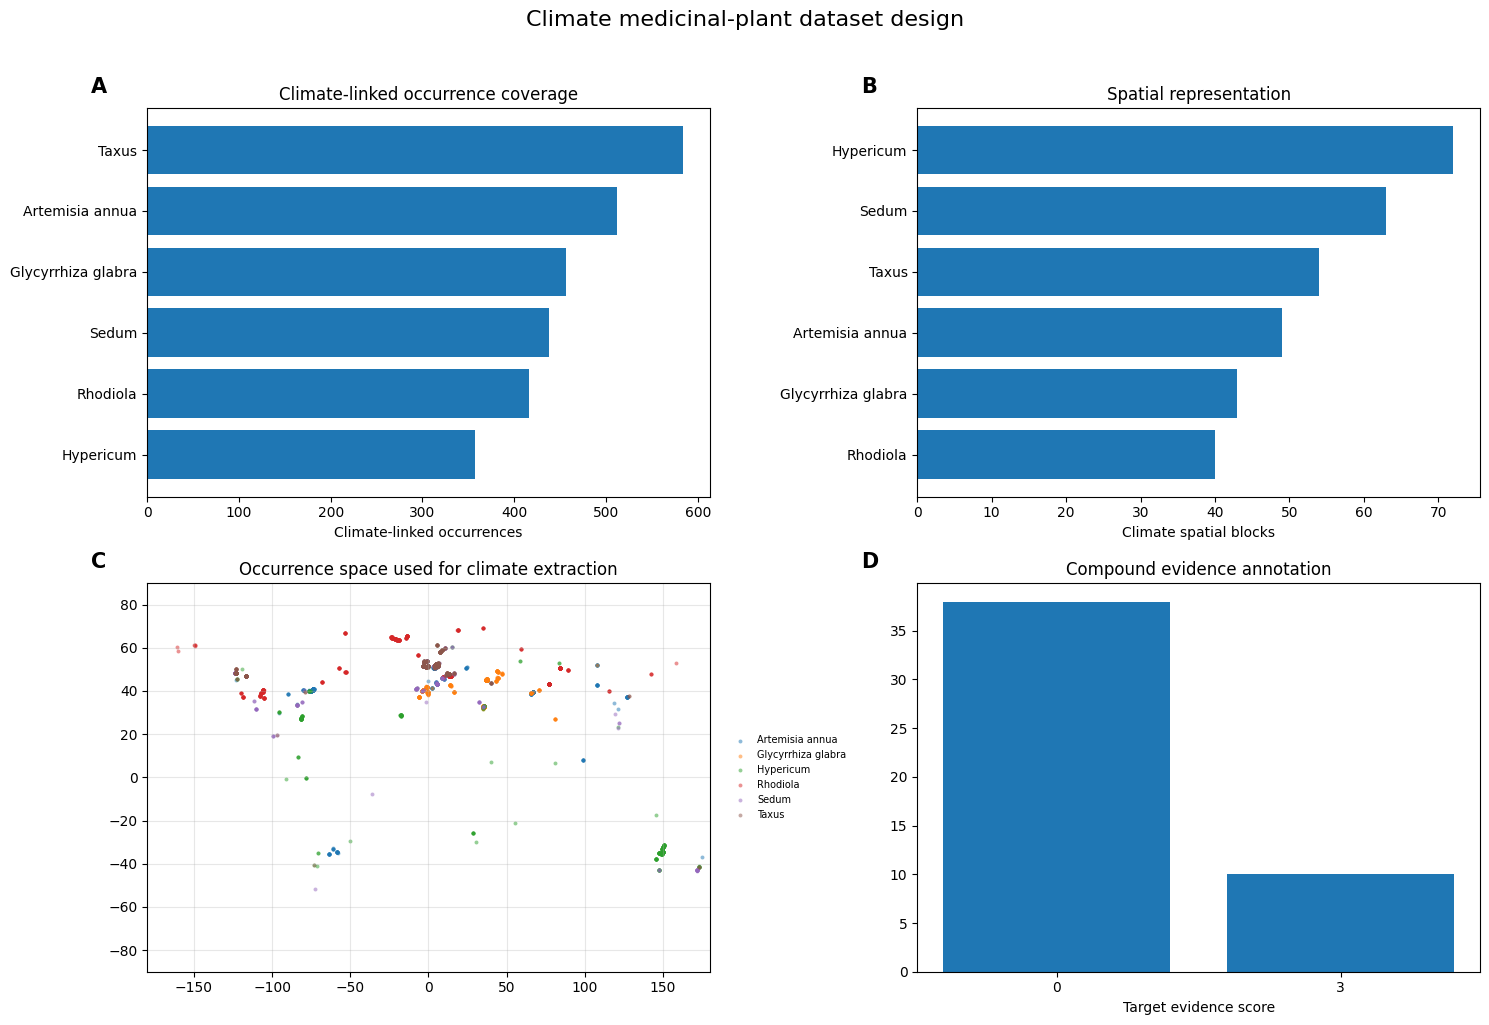

Saved: /content/climate_notebook2_outputs/figures/figure2C_climate_pca_correlation_profiles.png


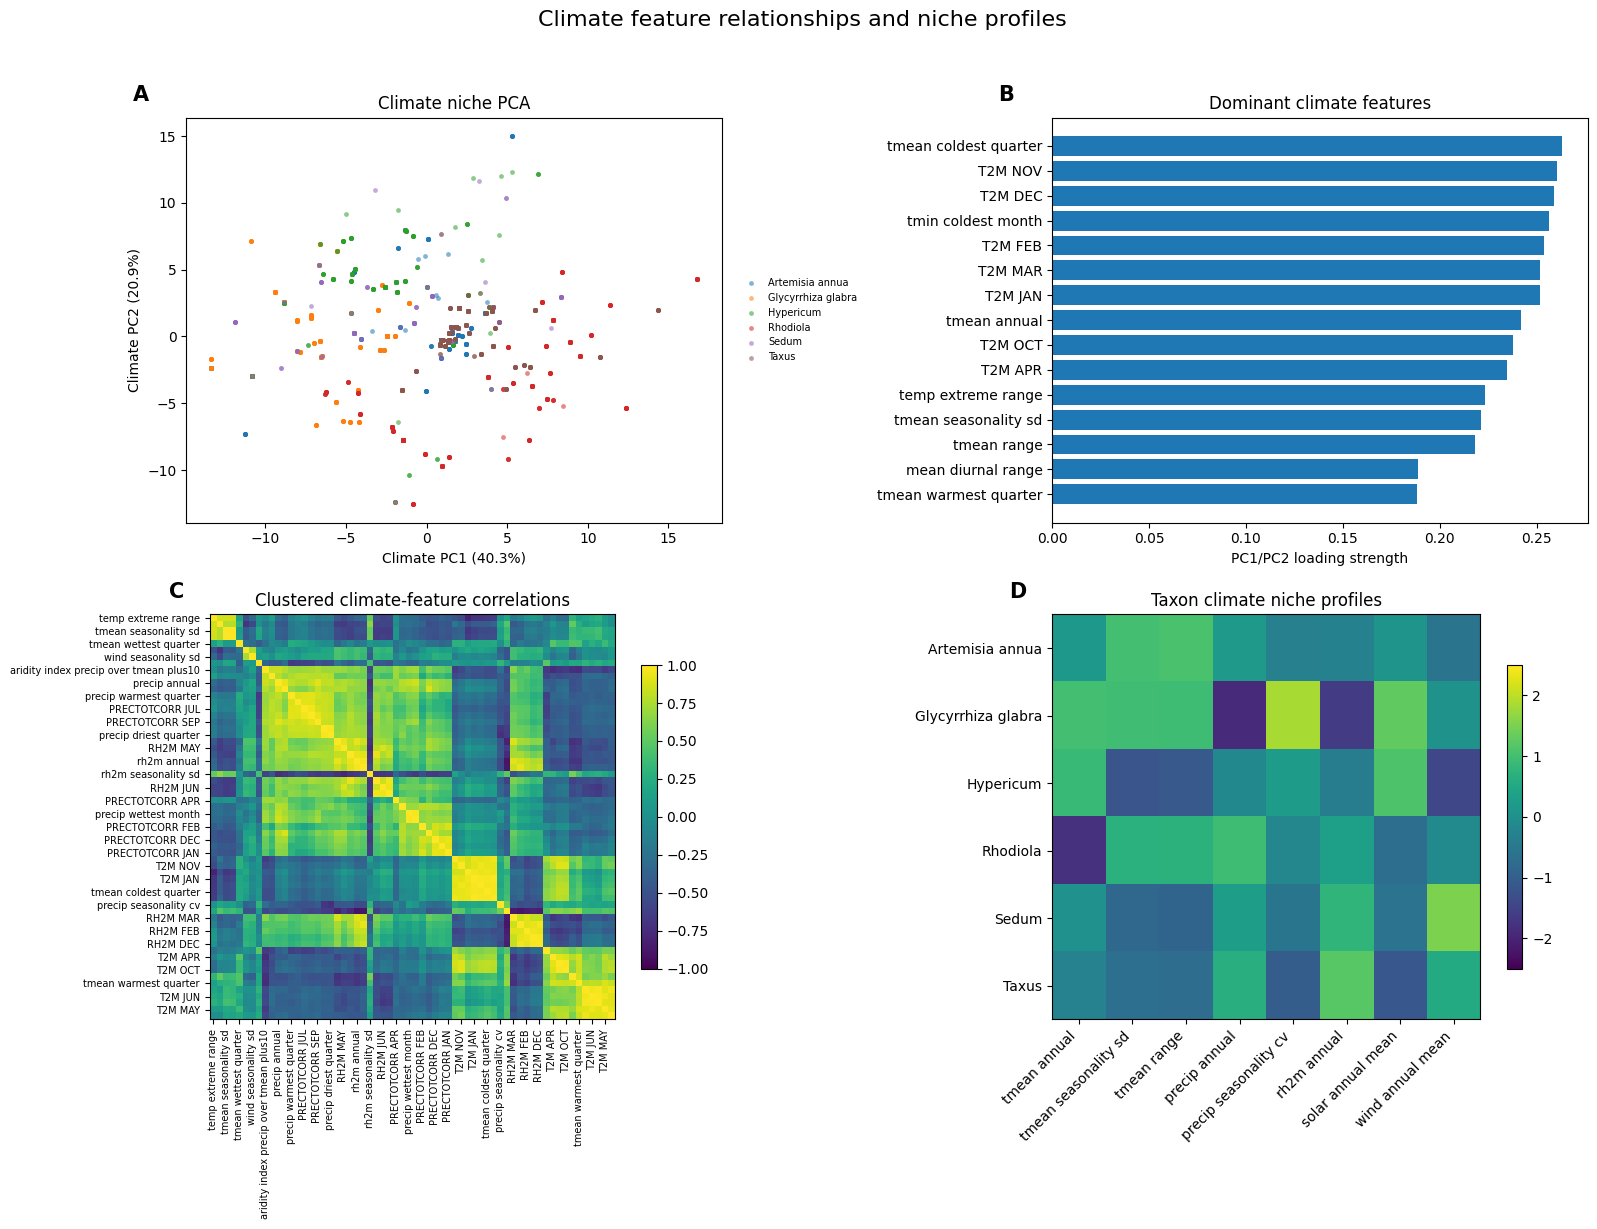

Saved: /content/climate_notebook2_outputs/figures/figure3C_compound_evidence_annotation.png


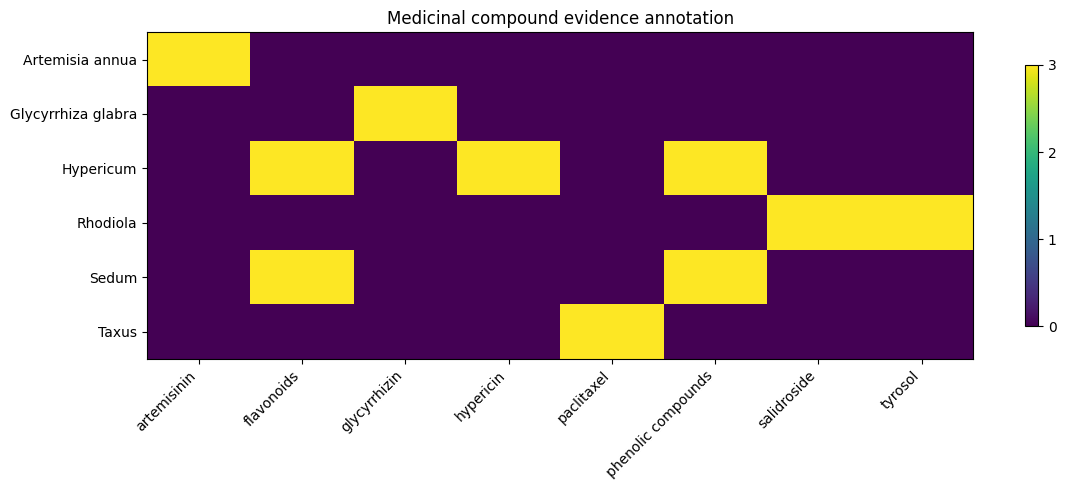

In [13]:
# ============================================================
# 5. Publication figures
# ============================================================

# Figure 1: design
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.reshape(-1)

counts = occ_climate_df.groupby("input_taxon").size().sort_values()
axes[0].barh(counts.index, counts.values)
axes[0].set_xlabel("Climate-linked occurrences")
axes[0].set_title("Climate-linked occurrence coverage")
panel(axes[0], "A")

blocks = occ_climate_df.groupby("input_taxon")["spatial_block_id"].nunique().sort_values()
axes[1].barh(blocks.index, blocks.values)
axes[1].set_xlabel("Climate spatial blocks")
axes[1].set_title("Spatial representation")
panel(axes[1], "B")

for taxon, sub in occ_climate_df.groupby("input_taxon"):
    axes[2].scatter(pd.to_numeric(sub["decimal_longitude"], errors="coerce"),
                    pd.to_numeric(sub["decimal_latitude"], errors="coerce"),
                    s=8, alpha=0.5, linewidths=0, label=taxon)
axes[2].set_xlim(-180, 180)
axes[2].set_ylim(-90, 90)
axes[2].grid(True, alpha=0.3)
axes[2].set_title("Occurrence space used for climate extraction")
axes[2].legend(fontsize=7, frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
panel(axes[2], "C")

tc = primary_df["target_evidence_score"].value_counts().sort_index()
axes[3].bar([str(x) for x in tc.index], tc.values)
axes[3].set_xlabel("Target evidence score")
axes[3].set_title("Compound evidence annotation")
panel(axes[3], "D")

fig.suptitle("Climate medicinal-plant dataset design", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure1C_climate_dataset_design")
plt.show()

# Figure 2: PCA and correlation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.reshape(-1)

for taxon, sub in pca_scores_df.groupby("input_taxon"):
    axes[0].scatter(sub["PC1"], sub["PC2"], s=12, alpha=0.55, linewidths=0, label=taxon)
axes[0].set_xlabel(f"Climate PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"Climate PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("Climate niche PCA")
axes[0].legend(fontsize=7, frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
panel(axes[0], "A")

load = pca_loadings_df.copy()
load["strength"] = np.sqrt(load["PC1"]**2 + load["PC2"]**2)
top = load.sort_values("strength", ascending=False).head(15).iloc[::-1]
axes[1].barh([short_climate_name(x) for x in top["climate_feature"]], top["strength"])
axes[1].set_xlabel("PC1/PC2 loading strength")
axes[1].set_title("Dominant climate features")
panel(axes[1], "B")

im = axes[2].imshow(corr_ordered.values, vmin=-1, vmax=1, interpolation="nearest")
features = corr_ordered.index.tolist()
step = max(1, len(features) // 25)
ticks = list(range(0, len(features), step))
axes[2].set_xticks(ticks)
axes[2].set_yticks(ticks)
axes[2].set_xticklabels([short_climate_name(features[i]) for i in ticks], rotation=90, fontsize=7)
axes[2].set_yticklabels([short_climate_name(features[i]) for i in ticks], fontsize=7)
axes[2].set_title("Clustered climate-feature correlations")
fig.colorbar(im, ax=axes[2], shrink=0.75)
panel(axes[2], "C")

im2 = axes[3].imshow(taxon_climate_profile_z.values, aspect="auto", vmin=-2.5, vmax=2.5)
axes[3].set_yticks(range(len(taxon_climate_profile_z.index)))
axes[3].set_yticklabels(taxon_climate_profile_z.index)
axes[3].set_xticks(range(len(taxon_climate_profile_z.columns)))
axes[3].set_xticklabels([short_climate_name(c) for c in taxon_climate_profile_z.columns], rotation=45, ha="right")
axes[3].set_title("Taxon climate niche profiles")
fig.colorbar(im2, ax=axes[3], shrink=0.75)
panel(axes[3], "D")

fig.suptitle("Climate feature relationships and niche profiles", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure2C_climate_pca_correlation_profiles")
plt.show()

# Figure 3: compound evidence
target_pivot = primary_df.pivot_table(index="scientific_name", columns="compound_name", values="target_evidence_score", aggfunc="max", fill_value=0)
fig, ax = plt.subplots(figsize=(12, max(5, 0.55 * len(target_pivot))))
im = ax.imshow(target_pivot.values, aspect="auto", vmin=0, vmax=3)
ax.set_yticks(range(len(target_pivot.index)))
ax.set_yticklabels(target_pivot.index)
ax.set_xticks(range(len(target_pivot.columns)))
ax.set_xticklabels(target_pivot.columns, rotation=45, ha="right")
fig.colorbar(im, ax=ax, shrink=0.8, ticks=[0, 1, 2, 3])
ax.set_title("Medicinal compound evidence annotation")
fig.tight_layout()
save_figure(fig, "figure3C_compound_evidence_annotation")
plt.show()

In [14]:
# ============================================================
# 6. Notebook 3C handoff
# ============================================================

validation_groups_df = ml_table[[
    "ml_row_id", "taxon_id", "compound_id", "spatial_group_id",
    "taxonomic_group_id", "compound_group_id", "source_group_id",
    "target_evidence_score", "target_label_for_open_data_classifier"
]].copy()
validation_groups_df["recommended_primary_cv"] = "spatial_block_for_niche; taxon_and_compound_for_negative_control"
validation_groups_df["note"] = "Use climate occurrence/block table for climate-niche analysis; compound-level ML is a negative control."

write_table(validation_groups_df, DIRS["derived"] / "climate_validation_group_table_for_notebook3")
write_table(ml_table, DIRS["derived"] / "climate_occurrence_level_spatial_sensitivity_table")
write_table(primary_df, DIRS["derived"] / "climate_primary_taxon_compound_table")

handoff_df = pd.DataFrame([
    {"file_role": "occurrence_climate_features", "path": str(find_input_file("occurrence_climate_features.tsv")), "required_for_notebook3": True},
    {"file_role": "primary_taxon_compound_table", "path": str(DIRS["derived"] / "climate_primary_taxon_compound_table.tsv"), "required_for_notebook3": True},
    {"file_role": "occurrence_spatial_sensitivity_table", "path": str(DIRS["derived"] / "climate_occurrence_level_spatial_sensitivity_table.tsv"), "required_for_notebook3": True},
    {"file_role": "validation_groups", "path": str(DIRS["derived"] / "climate_validation_group_table_for_notebook3.tsv"), "required_for_notebook3": True},
    {"file_role": "climate_pca_scores", "path": str(DIRS["derived"] / "climate_pca_scores_occurrence.tsv"), "required_for_notebook3": False},
])
handoff_df["exists_and_nonempty"] = handoff_df["path"].apply(lambda x: pathlib.Path(x).exists() and pathlib.Path(x).stat().st_size > 0)
handoff_df["run_id"] = RUN_ID
write_table(handoff_df, DIRS["derived"] / "climate_notebook2C_handoff_manifest")
display(handoff_df)

qc_lines = [
    "# Notebook 2C climate QC report",
    f"Run ID: {RUN_ID}",
    f"Occurrence-climate rows: {len(occ_climate_df)}",
    f"Occurrence-compound rows: {len(ml_table)}",
    f"Primary taxon-compound rows: {len(primary_df)}",
    f"Climate features: {len(climate_feature_cols)}",
    "",
    "Climate variables are ecological niche covariates. Compound target is curated/open evidence, not measured concentration.",
]
qc_path = DIRS["derived"] / "climate_notebook2C_qc_report.md"
qc_path.write_text("\n".join(qc_lines), encoding="utf-8")

manifest_rows = []
for path in PROJECT.rglob("*"):
    if path.is_file():
        manifest_rows.append({"path": str(path.relative_to(PROJECT)), "bytes": path.stat().st_size, "run_id": RUN_ID})
run_manifest_df = pd.DataFrame(manifest_rows).sort_values("path")
write_table(run_manifest_df, PROJECT / "run_file_manifest")
print(qc_path)

,file_role,path,required_for_notebook3,exists_and_nonempty,run_id
0,occurrence_climate_features,extracted_notebook_outputs/derived/occurrence_...,True,True,20260515T064648Z
1,primary_taxon_compound_table,/content/climate_notebook2_outputs/derived/cli...,True,True,20260515T064648Z
2,occurrence_spatial_sensitivity_table,/content/climate_notebook2_outputs/derived/cli...,True,True,20260515T064648Z
3,validation_groups,/content/climate_notebook2_outputs/derived/cli...,True,True,20260515T064648Z
4,climate_pca_scores,/content/climate_notebook2_outputs/derived/cli...,False,True,20260515T064648Z


/content/climate_notebook2_outputs/derived/climate_notebook2C_qc_report.md


In [15]:
import shutil
from google.colab import files
import os

output_zip = "/content/climate_notebook2_outputs"
print(f"Zipping {PROJECT}...")
shutil.make_archive(output_zip, 'zip', PROJECT)

zip_file = output_zip + ".zip"
print(f"Downloading {zip_file}...")
files.download(zip_file)


Zipping /content/climate_notebook2_outputs...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>